# (23) gaussian: (16, 4.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Trainer

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'vH16', 'grad|lin')

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 4.0

cfg_vae['clamp_u'] = 3.0
cfg_vae['track_stats'] = True

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  132.9 K   |
|     ———     |    ———     |
|    layer    |  132.9 K   |
+-------------+------------+

gaussian_vH16_t-16_z-[512]_cl-3,5_<grad|lin>
b200-ep300-lr(0.002)_beta(4:0.1)_gr(500)_(2025_02_23,22:33)

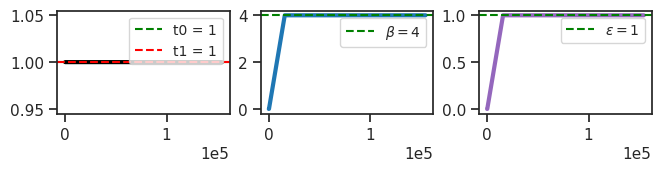

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer)
# print(tr.model.layer.n_exp)

GaussianLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

In [6]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>))

In [7]:
tr.train()

epoch # 300, avg loss: 199.331616: 100%|████| 300/300 [1:53:09<00:00, 22.63s/it]


In [8]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.5354], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([0.1802], device='cuda:0', grad_fn=<ExpBackward0>))

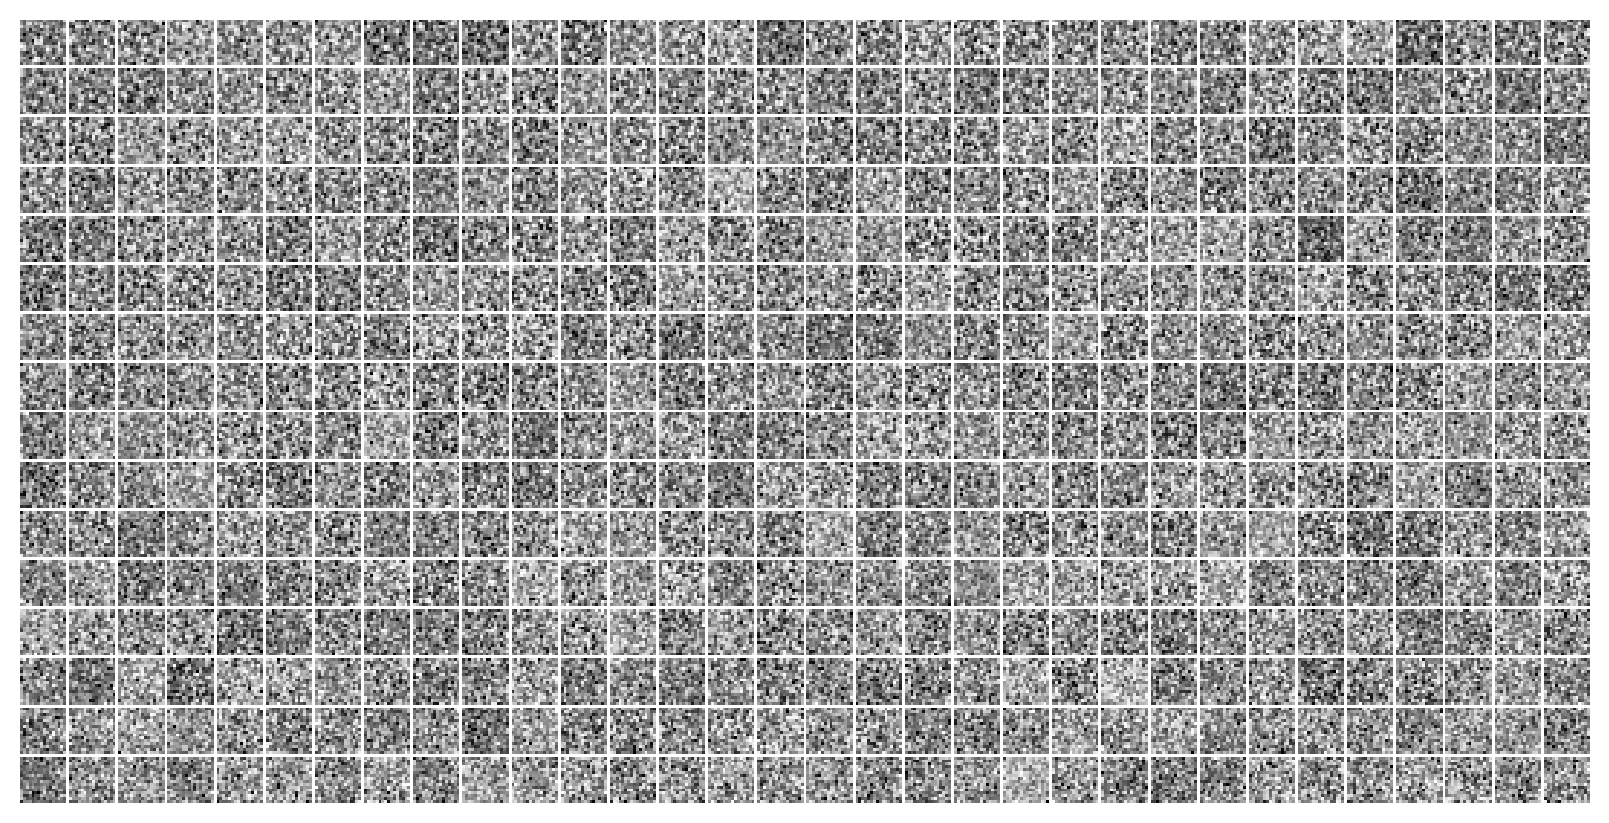

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u1));

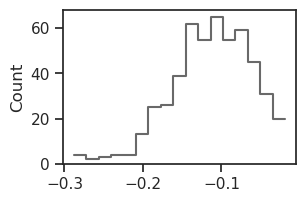

In [10]:
histplot(u0, color='dimgrey');

In [11]:
bias = tonp(tr.model.layer.log_bias.squeeze().exp())
bias

array([0.02150587, 0.02173449, 0.02059549, 0.02178442, 0.02110453,
       0.02170379, 0.02214829, 0.02182993, 0.02024766, 0.02170981,
       0.02097701, 0.02063033, 0.02079485, 0.02163256, 0.0208502 ,
       0.02103642, 0.02117198, 0.02154599, 0.02114599, 0.02131737,
       0.02081977, 0.0213331 , 0.02052015, 0.02111454, 0.02073735,
       0.02224109, 0.02099417, 0.02131691, 0.02130979, 0.02202872,
       0.02261883, 0.02109464, 0.02151929, 0.02052783, 0.02184735,
       0.02188168, 0.02117124, 0.02108234, 0.02116507, 0.02133139,
       0.0219654 , 0.02061981, 0.02042328, 0.02116644, 0.02024123,
       0.0203139 , 0.02054594, 0.02219908, 0.02181485, 0.02177565,
       0.02137856, 0.02164874, 0.02219297, 0.02186905, 0.02171906,
       0.0207255 , 0.02067713, 0.02107453, 0.02228001, 0.02197783,
       0.0204116 , 0.02066554, 0.02179791, 0.02220508, 0.02173217,
       0.020731  , 0.02080951, 0.02105066, 0.02255828, 0.02116431,
       0.020782  , 0.02129786, 0.02289136, 0.02180214, 0.02126

In [ ]:
fig, ax = create_figure()

sns.histplot(bias, label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

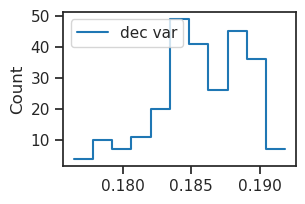

In [12]:
log_scale = tonp(tr.model.layer.log_sigma_dec.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

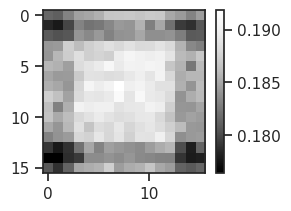

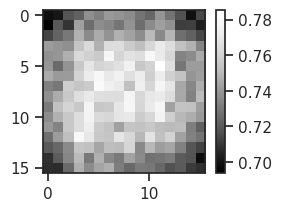

In [13]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar()
plt.show()

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar()
plt.show()

100%|███████████████████████████████████| 2/2 [00:31<00:00, 15.62s/it]


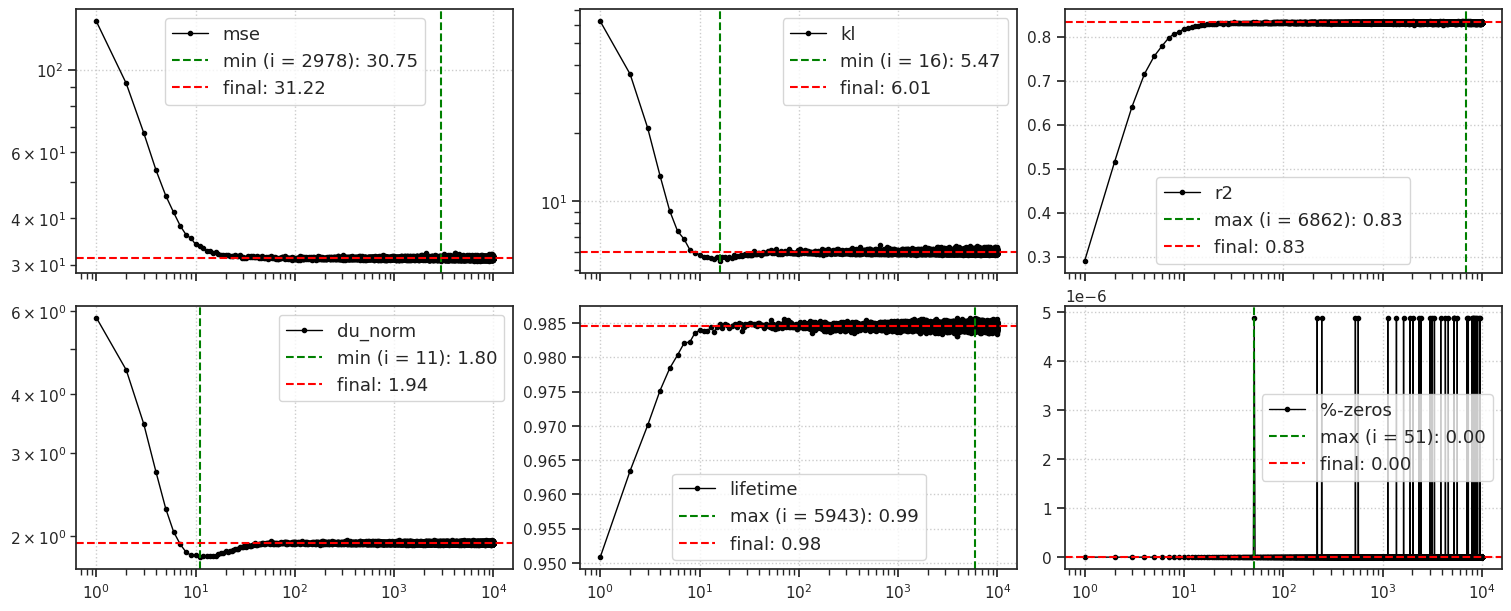

CPU times: user 40.6 s, sys: 1.82 s, total: 42.4 s
Wall time: 42.4 s


In [14]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.82s/it]


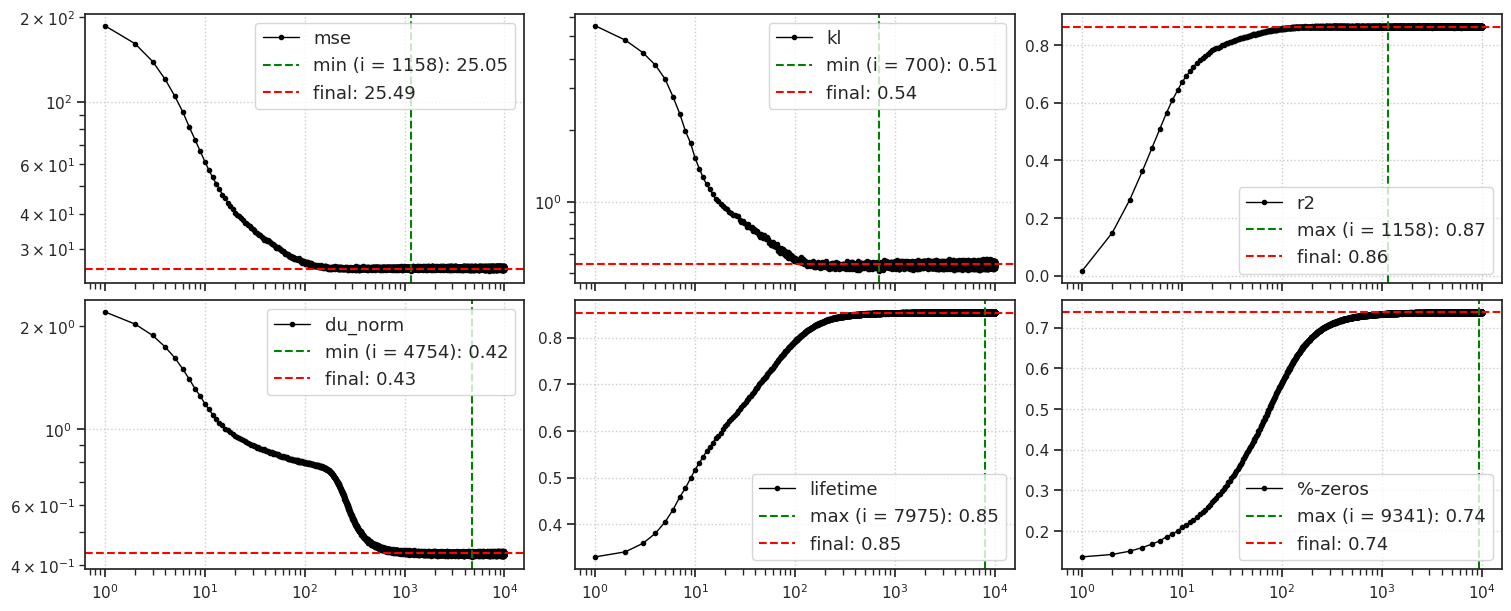

CPU times: user 50 s, sys: 2.79 s, total: 52.8 s
Wall time: 52.8 s


In [15]:
### Was: beta = 20.0

## output

In [15]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

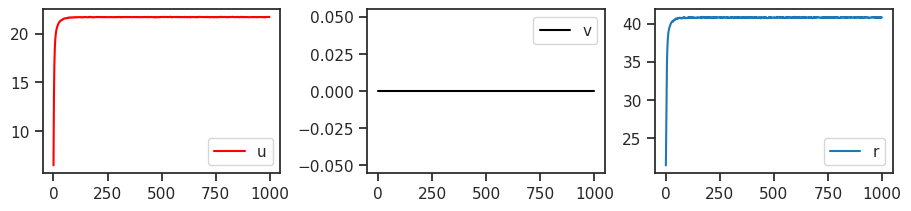

In [16]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

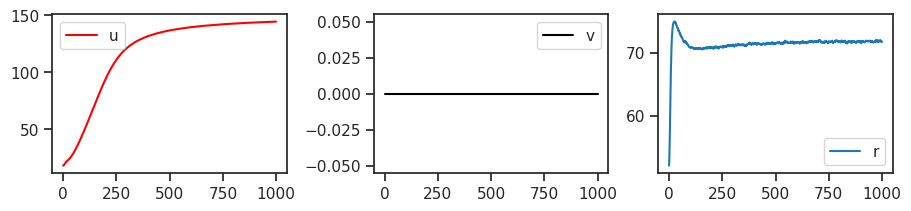

In [17]:
### Was: beta = 20.0

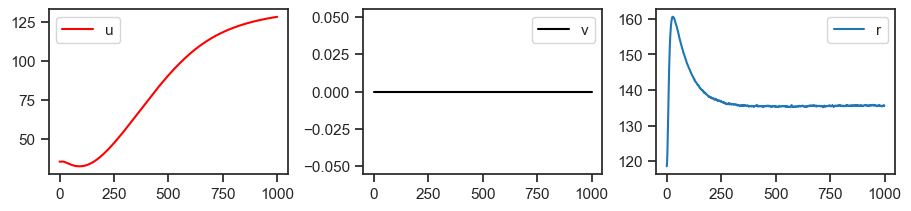

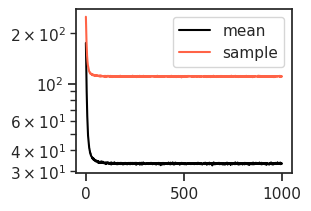

(tensor([33.2694, 33.3789, 33.4355, 33.3928, 33.2773], device='cuda:1'),
 tensor([110.8249, 110.8921, 110.5431, 110.6891, 110.5299], device='cuda:1'))

In [19]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)

samples = torch.stack([
    p.sample() for p in
    output['conditional'].values()
], dim=1)

mse_locs = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
mse_samples = (samples - feeder[0].unsqueeze(1)).pow(2).sum(-1)

fig, ax = create_figure()
ax.plot(tonp(mse_locs.mean(0)), color='k', label='mean')
ax.plot(tonp(mse_samples.mean(0)), color='tomato', label='sample')
ax.set_yscale('log')
add_legend(ax)
plt.show()

mse_locs.mean(0)[-5:], mse_samples.mean(0)[-5:]

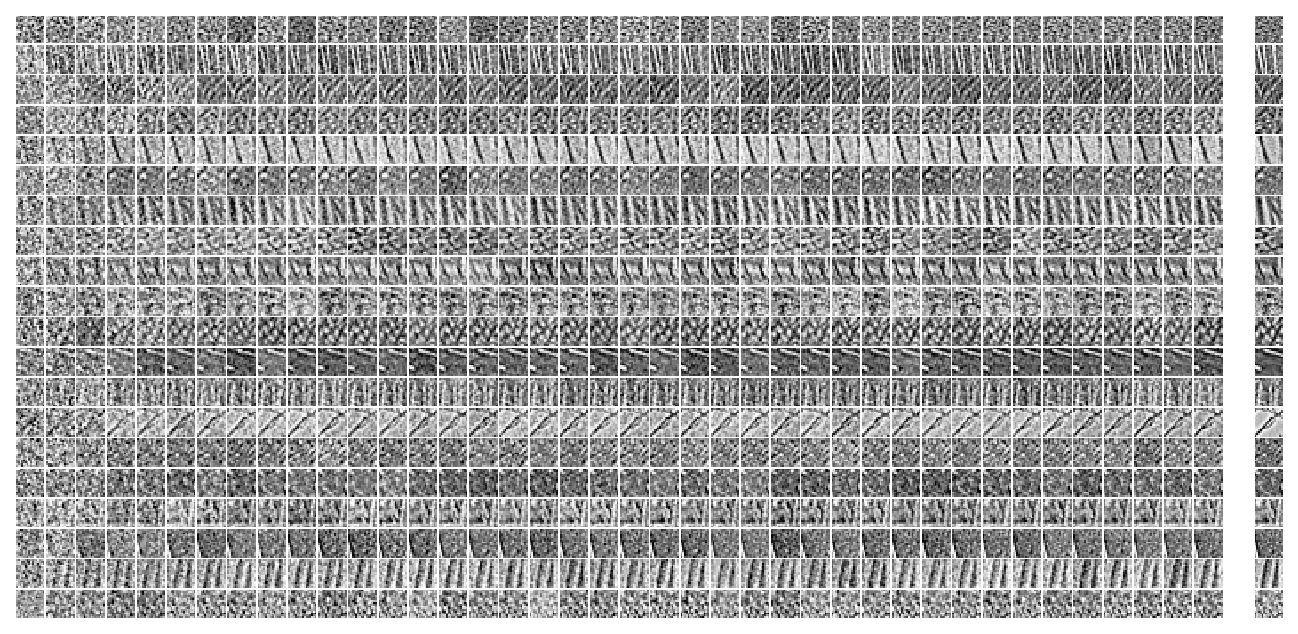

In [20]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

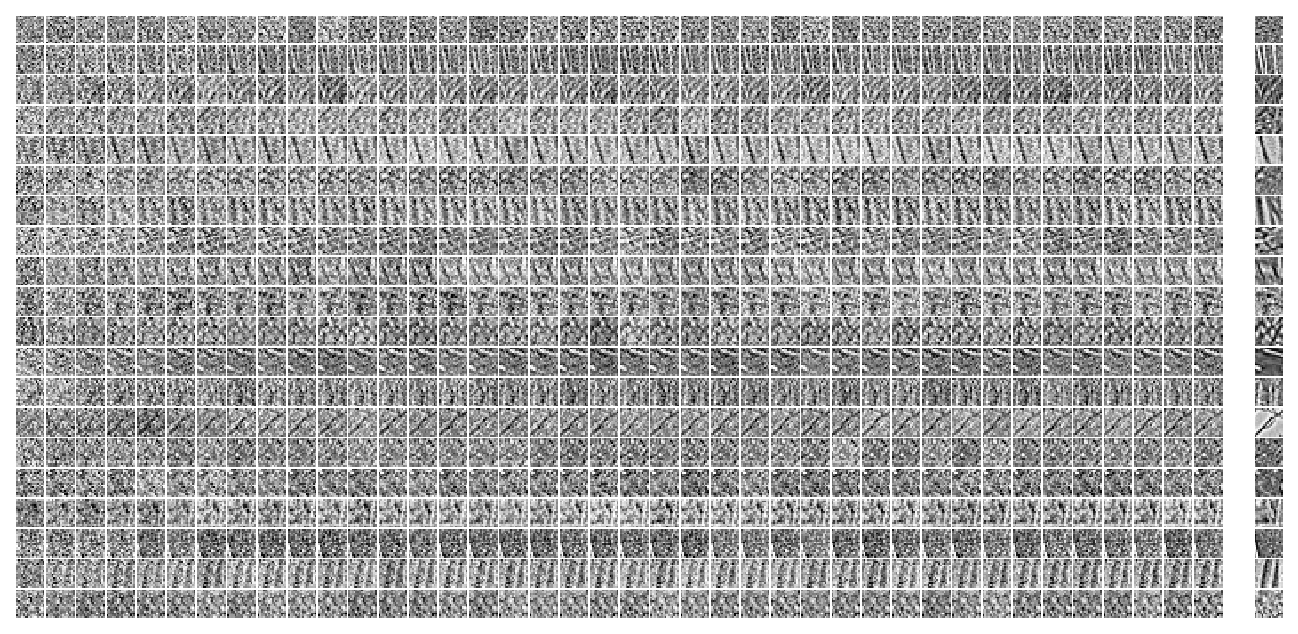

In [21]:
x2p = tonp(samples)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)